
# NeuroFHIR-TRACE — Notebook 19A
## Evidence Family, Provenance, Stability Analytics, Reliability Gate, and FHIR Trace



This notebook implements the first core TRACE chain:

1. repeated patient/visit evidence families;
2. technical provenance;
3. controlled perturbations;
4. patient-level stability metrics;
5. TRUSTED / CAUTION / REVIEW_REQUIRED gating;
6. FHIR-oriented evidence propagation.

It is designed as the foundation for the later real longitudinal/test-retest validation and downstream Model A/B/C experiments.


In [1]:

!pip -q install pandas numpy scipy scikit-learn pyarrow matplotlib

from pathlib import Path
import json, hashlib, random
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

ROOT = Path("/content/neurofhir_trace")
OUT_DIR = ROOT / "outputs"
FHIR_DIR = OUT_DIR / "fhir"
FIG_DIR = OUT_DIR / "figures"

for p in [OUT_DIR, FHIR_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

TRACE_CONFIG = {
    "project": "NeuroFHIR-TRACE",
    "version": "0.1.0",
    "biomarker_name": "hippocampal_volume_mm3",
    "biomarker_unit": "mm3",
    "model_name": "NeuroFHIR-Segmentation",
    "model_version": "v1.0",
    "preprocessing_version": "prep_v1",
    "thresholds": {
        "cv_trusted_max": 0.05,
        "cv_review_min": 0.12,
        "direction_trusted_min": 0.90,
        "direction_review_max": 0.65,
        "domain_caution_min": 2.0,
        "domain_review_min": 3.5,
        "provenance_trusted_min": 0.95
    }
}
TRACE_CONFIG


{'project': 'NeuroFHIR-TRACE',
 'version': '0.1.0',
 'biomarker_name': 'hippocampal_volume_mm3',
 'biomarker_unit': 'mm3',
 'model_name': 'NeuroFHIR-Segmentation',
 'model_version': 'v1.0',
 'preprocessing_version': 'prep_v1',
 'thresholds': {'cv_trusted_max': 0.05,
  'cv_review_min': 0.12,
  'direction_trusted_min': 0.9,
  'direction_review_max': 0.65,
  'domain_caution_min': 2.0,
  'domain_review_min': 3.5,
  'provenance_trusted_min': 0.95}}


## 1. Provenance manifest

Every inference result should carry subject, visit, source image, site/scanner/sequence, preprocessing version, model version, perturbation configuration, timestamp, and output hash.


In [2]:

def sha256_bytes(payload: bytes) -> str:
    return hashlib.sha256(payload).hexdigest()

def build_trace_manifest(row):
    payload = {
        "trace_schema_version": "0.1",
        "subject_id": str(row["subject_id"]),
        "visit_id": str(row["visit_id"]),
        "source_image": f'{row["subject_id"]}_{row["visit_id"]}_T1w.nii.gz',
        "site": row["site"],
        "scanner": row["scanner"],
        "sequence": row["sequence"],
        "preprocessing_version": row["preprocessing_version"],
        "model_name": TRACE_CONFIG["model_name"],
        "model_version": row["model_version"],
        "perturbation": row["perturbation"],
        "provenance_completeness": float(row["provenance_completeness"]),
        "biomarker_name": TRACE_CONFIG["biomarker_name"],
        "biomarker_value": float(row["biomarker_value"]),
        "biomarker_unit": TRACE_CONFIG["biomarker_unit"],
        "timestamp_utc": datetime.now(timezone.utc).isoformat()
    }
    payload["output_artifact_hash"] = sha256_bytes(
        json.dumps(payload, sort_keys=True).encode("utf-8")
    )
    return payload



## 2. Synthetic runnable evidence family

This demonstration makes the notebook executable before ADNI-derived data are attached. Replace this section with real NeuroFHIR/ADNI outputs later.


In [3]:

subjects = [f"S{i:03d}" for i in range(1, 61)]
visits = ["BL", "M12"]
rows = []

for sid in subjects:
    base = np.random.normal(3600, 350)
    biological_delta = np.random.normal(-60, 70)
    subject_instability = np.random.beta(2, 8)

    for visit in visits:
        clean_value = base if visit == "BL" else base + biological_delta

        perturbations = [
            ("clean", 0.00, "v1.0", "prep_v1", 1.00),
            ("noise_low", 0.02, "v1.0", "prep_v1", 1.00),
            ("noise_high", 0.08, "v1.0", "prep_v1", 1.00),
            ("intensity_scale", 0.04, "v1.0", "prep_v1", 1.00),
            ("blur", 0.06, "v1.0", "prep_v1", 1.00),
            ("resample_alt", 0.07, "v1.0", "prep_v2", 1.00),
            ("model_v2", 0.09, "v2.0", "prep_v1", 1.00),
            ("missing_context", 0.03, "v1.0", "prep_v1", 0.70),
        ]

        for perturbation, scale, model_version, prep_version, prov in perturbations:
            technical_shift = np.random.normal(
                0, clean_value * scale * (0.3 + 2.0 * subject_instability)
            )

            if subject_instability > 0.55 and perturbation in {"blur", "resample_alt", "model_v2"}:
                technical_shift += np.random.choice([-1, 1]) * clean_value * np.random.uniform(0.10, 0.22)

            value = max(100, clean_value + technical_shift)

            rows.append({
                "subject_id": sid,
                "visit_id": visit,
                "site": np.random.choice(["SITE_A", "SITE_B", "SITE_C"]),
                "scanner": np.random.choice(["3T_A", "3T_B"]),
                "sequence": "T1w",
                "perturbation": perturbation,
                "model_version": model_version,
                "preprocessing_version": prep_version,
                "provenance_completeness": prov,
                "biomarker_value": value,
                "clean_reference_value": clean_value,
                "known_technical_shift_abs": abs(value-clean_value)
            })

evidence = pd.DataFrame(rows)

denom = evidence.groupby(["subject_id","visit_id"])["biomarker_value"].transform("std").replace(0, np.nan)
evidence["domain_distance"] = (evidence["known_technical_shift_abs"]/denom).fillna(0).clip(0,6)

evidence.to_parquet(OUT_DIR/"evidence_family.parquet", index=False)
evidence.head()


,subject_id,visit_id,site,scanner,sequence,perturbation,model_version,preprocessing_version,provenance_completeness,biomarker_value,clean_reference_value,known_technical_shift_abs,domain_distance
0,S001,BL,SITE_B,3T_A,T1w,clean,v1.0,prep_v1,1.0,3773.849954,3773.849954,0.000000,0.000000
1,S001,BL,SITE_B,3T_B,T1w,noise_low,v1.0,prep_v1,1.0,3811.224132,3773.849954,37.374179,0.202254
2,S001,BL,SITE_A,3T_A,T1w,noise_high,v1.0,prep_v1,1.0,3682.396081,3773.849954,91.453873,0.494912
3,S001,BL,SITE_B,3T_B,T1w,intensity_scale,v1.0,prep_v1,1.0,3826.695453,3773.849954,52.845500,0.285979
4,S001,BL,SITE_C,3T_B,T1w,blur,v1.0,prep_v1,1.0,3417.495571,3773.849954,356.354382,1.928448


In [4]:

manifests = [build_trace_manifest(r) for _, r in evidence.head(10).iterrows()]
with open(OUT_DIR/"trace_manifest.json", "w") as f:
    json.dump(manifests, f, indent=2)

print(json.dumps(manifests[0], indent=2))


{
  "trace_schema_version": "0.1",
  "subject_id": "S001",
  "visit_id": "BL",
  "source_image": "S001_BL_T1w.nii.gz",
  "site": "SITE_B",
  "scanner": "3T_A",
  "sequence": "T1w",
  "preprocessing_version": "prep_v1",
  "model_name": "NeuroFHIR-Segmentation",
  "model_version": "v1.0",
  "perturbation": "clean",
  "provenance_completeness": 1.0,
  "biomarker_name": "hippocampal_volume_mm3",
  "biomarker_value": 3773.8499535539313,
  "biomarker_unit": "mm3",
  "timestamp_utc": "2026-09-11T20:57:08.675943+00:00",
  "output_artifact_hash": "be85516fd6326cdeb10a3cb7c85179fa9c88fec162b78a2b93483f5431051df9"
}



## 3. Patient × visit stability metrics


In [5]:

def visit_stability_summary(df):
    out = []
    for (sid, visit), g in df.groupby(["subject_id","visit_id"]):
        clean = g.loc[g["perturbation"]=="clean","biomarker_value"]
        clean_val = float(clean.iloc[0]) if len(clean) else float(g["biomarker_value"].median())

        vals = g["biomarker_value"].astype(float)
        mean = vals.mean()
        sd = vals.std(ddof=1)

        out.append({
            "subject_id": sid,
            "visit_id": visit,
            "clean_value": clean_val,
            "mean_value": mean,
            "sd": sd,
            "cv": sd/abs(mean) if mean != 0 else np.nan,
            "relative_range": (vals.max()-vals.min())/abs(clean_val),
            "mean_relative_error": np.mean(np.abs(vals-clean_val)/abs(clean_val)),
            "max_domain_distance": g["domain_distance"].max(),
            "mean_provenance_completeness": g["provenance_completeness"].mean()
        })
    return pd.DataFrame(out)

visit_stability = visit_stability_summary(evidence)
visit_stability.head()


,subject_id,visit_id,clean_value,mean_value,sd,cv,relative_range,mean_relative_error,max_domain_distance,mean_provenance_completeness
0,S001,BL,3773.849954,3715.144199,184.788213,0.049739,0.123211,0.035542,1.928448,0.9625
1,S001,M12,3704.171452,3668.798572,173.043767,0.047166,0.134782,0.032369,2.239414,0.9625
2,S002,BL,3135.134883,3112.875293,167.022490,0.053655,0.159622,0.036453,1.717820,0.9625
3,S002,M12,3088.915169,3046.802302,154.588736,0.050738,0.160627,0.034616,1.993138,0.9625
4,S003,BL,3384.793484,3373.253922,67.834842,0.020110,0.065539,0.012537,2.382299,0.9625



## 4. Longitudinal change-direction stability

The ICHI paper should test whether technical changes flip an apparent longitudinal increase/decrease/stable interpretation.


In [6]:

def classify_change(delta, baseline, pct_threshold=0.02):
    t = abs(baseline)*pct_threshold
    if delta > t:
        return "INCREASE"
    if delta < -t:
        return "DECREASE"
    return "STABLE"

long_rows = []

for sid, g in evidence.groupby("subject_id"):
    for perturbation in sorted(g["perturbation"].unique()):
        b = g[(g.visit_id=="BL") & (g.perturbation==perturbation)]
        f = g[(g.visit_id=="M12") & (g.perturbation==perturbation)]
        if len(b)==0 or len(f)==0:
            continue

        bval = float(b.iloc[0].biomarker_value)
        fval = float(f.iloc[0].biomarker_value)
        long_rows.append({
            "subject_id": sid,
            "perturbation": perturbation,
            "baseline_value": bval,
            "followup_value": fval,
            "delta": fval-bval,
            "direction": classify_change(fval-bval, bval)
        })

longitudinal = pd.DataFrame(long_rows)

clean_dir = longitudinal[longitudinal.perturbation=="clean"][["subject_id","direction"]].rename(
    columns={"direction":"clean_direction"}
)
longitudinal = longitudinal.merge(clean_dir, on="subject_id", how="left")
longitudinal["direction_preserved"] = (longitudinal.direction==longitudinal.clean_direction).astype(int)

direction_stability = longitudinal.groupby("subject_id", as_index=False).agg(
    direction_stability=("direction_preserved","mean")
)

direction_stability.head()


,subject_id,direction_stability
0,S001,0.375
1,S002,0.375
2,S003,0.625
3,S004,1.000
4,S005,0.750



## 5. Experimental instability reference

This label is only for controlled technical-instability evaluation. It is **not clinical ground truth**.


In [7]:

visit_stability["unstable_reference"] = (
    (visit_stability["cv"] >= 0.12) |
    (visit_stability["relative_range"] >= 0.20) |
    (visit_stability["max_domain_distance"] >= 3.5)
).astype(int)

analysis = visit_stability.merge(direction_stability, on="subject_id", how="left")
analysis["unstable_reference"] = (
    (analysis["unstable_reference"]==1) |
    (analysis["direction_stability"]<0.70)
).astype(int)

analysis["unstable_reference"].value_counts()


,count
unstable_reference,
1,93
0,27



## 6. Interpretable TRACE gate

Final thresholds must be calibrated on development subjects and frozen before held-out/external evaluation.


In [8]:

T = TRACE_CONFIG["thresholds"]

def trace_gate(row):
    reasons = []
    sev = 0

    if row.cv >= T["cv_review_min"]:
        reasons.append("HIGH_OUTPUT_VARIABILITY"); sev = max(sev,2)
    elif row.cv > T["cv_trusted_max"]:
        reasons.append("MODERATE_OUTPUT_VARIABILITY"); sev = max(sev,1)

    if row.direction_stability <= T["direction_review_max"]:
        reasons.append("LONGITUDINAL_DIRECTION_UNSTABLE"); sev = max(sev,2)
    elif row.direction_stability < T["direction_trusted_min"]:
        reasons.append("LONGITUDINAL_DIRECTION_PARTIALLY_STABLE"); sev = max(sev,1)

    if row.max_domain_distance >= T["domain_review_min"]:
        reasons.append("HIGH_DOMAIN_DISTANCE"); sev = max(sev,2)
    elif row.max_domain_distance >= T["domain_caution_min"]:
        reasons.append("MODERATE_DOMAIN_DISTANCE"); sev = max(sev,1)

    if row.mean_provenance_completeness < 0.80:
        reasons.append("PROVENANCE_INCOMPLETE"); sev = max(sev,2)
    elif row.mean_provenance_completeness < T["provenance_trusted_min"]:
        reasons.append("PROVENANCE_PARTIAL"); sev = max(sev,1)

    state = ["TRUSTED","CAUTION","REVIEW_REQUIRED"][sev]

    score = 1.0
    score -= min(row.cv/0.20,1.0)*0.35
    score -= (1-row.direction_stability)*0.30
    score -= min(row.max_domain_distance/5.0,1.0)*0.20
    score -= (1-row.mean_provenance_completeness)*0.15

    return pd.Series({
        "trace_state": state,
        "trace_score": float(np.clip(score,0,1)),
        "trace_reasons": reasons if reasons else ["NO_MAJOR_INSTABILITY_DETECTED"]
    })

gate_output = analysis.join(analysis.apply(trace_gate, axis=1))
gate_output.to_csv(OUT_DIR/"trace_stability_summary.csv", index=False)

with open(OUT_DIR/"trace_reliability.json","w") as f:
    json.dump(gate_output.to_dict(orient="records"), f, indent=2)

gate_output.head()


,subject_id,visit_id,clean_value,mean_value,sd,cv,relative_range,mean_relative_error,max_domain_distance,mean_provenance_completeness,unstable_reference,direction_stability,trace_state,trace_score,trace_reasons
0,S001,BL,3773.849954,3715.144199,184.788213,0.049739,0.123211,0.035542,1.928448,0.9625,1,0.375,REVIEW_REQUIRED,0.642694,[LONGITUDINAL_DIRECTION_UNSTABLE]
1,S001,M12,3704.171452,3668.798572,173.043767,0.047166,0.134782,0.032369,2.239414,0.9625,1,0.375,REVIEW_REQUIRED,0.634757,"[LONGITUDINAL_DIRECTION_UNSTABLE, MODERATE_DOM..."
2,S002,BL,3135.134883,3112.875293,167.022490,0.053655,0.159622,0.036453,1.717820,0.9625,1,0.375,REVIEW_REQUIRED,0.644265,"[MODERATE_OUTPUT_VARIABILITY, LONGITUDINAL_DIR..."
3,S002,M12,3088.915169,3046.802302,154.588736,0.050738,0.160627,0.034616,1.993138,0.9625,1,0.375,REVIEW_REQUIRED,0.638358,"[MODERATE_OUTPUT_VARIABILITY, LONGITUDINAL_DIR..."
4,S003,BL,3384.793484,3373.253922,67.834842,0.020110,0.065539,0.012537,2.382299,0.9625,1,0.625,REVIEW_REQUIRED,0.751391,"[LONGITUDINAL_DIRECTION_UNSTABLE, MODERATE_DOM..."



## 7. Gate discrimination


In [9]:

y_true = gate_output["unstable_reference"].values
risk_score = 1-gate_output["trace_score"].values

auroc = roc_auc_score(y_true, risk_score) if len(np.unique(y_true))==2 else np.nan
auprc = average_precision_score(y_true, risk_score) if len(np.unique(y_true))==2 else np.nan

gate_output["predicted_unstable"] = (gate_output.trace_state=="REVIEW_REQUIRED").astype(int)

pd.DataFrame([{
    "AUROC": auroc,
    "AUPRC": auprc,
    "Review_required_fraction": (gate_output.trace_state=="REVIEW_REQUIRED").mean()
}])


,AUROC,AUPRC,Review_required_fraction
0,0.966945,0.990043,0.75



## 8. False longitudinal change rate


In [10]:

nonclean = longitudinal[longitudinal.perturbation!="clean"].copy()
nonclean["false_change_event"] = (nonclean.direction!=nonclean.clean_direction).astype(int)

subject_gate = gate_output.groupby("subject_id", as_index=False).agg(
    subject_trace_state=("trace_state", lambda s:
        "REVIEW_REQUIRED" if "REVIEW_REQUIRED" in set(s)
        else ("CAUTION" if "CAUTION" in set(s) else "TRUSTED"))
)

nonclean = nonclean.merge(subject_gate, on="subject_id", how="left")

raw_false_change_rate = nonclean.false_change_event.mean()
propagated = nonclean[nonclean.subject_trace_state!="REVIEW_REQUIRED"]
trace_false_change_rate = propagated.false_change_event.mean() if len(propagated) else np.nan

pd.DataFrame([{
    "raw_false_change_rate": raw_false_change_rate,
    "TRACE_propagated_false_change_rate": trace_false_change_rate,
    "review_required_subject_fraction": (subject_gate.subject_trace_state=="REVIEW_REQUIRED").mean()
}])


,raw_false_change_rate,TRACE_propagated_false_change_rate,review_required_subject_fraction
0,0.530952,0.2,0.75



## 9. TRACE stability figure


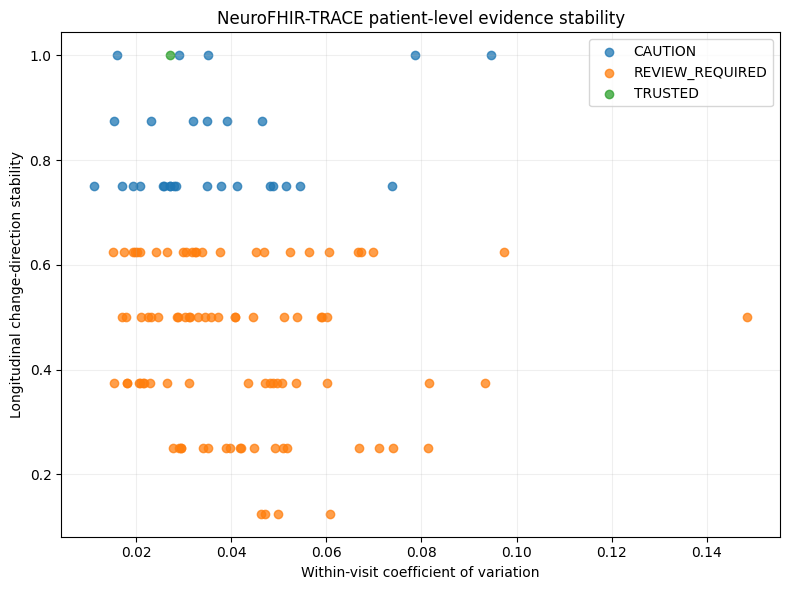

In [11]:

fig, ax = plt.subplots(figsize=(8,6))

for state, g in gate_output.groupby("trace_state"):
    ax.scatter(g.cv, g.direction_stability, label=state, alpha=0.75)

ax.set_xlabel("Within-visit coefficient of variation")
ax.set_ylabel("Longitudinal change-direction stability")
ax.set_title("NeuroFHIR-TRACE patient-level evidence stability")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR/"trace_stability_gate.png", dpi=300, bbox_inches="tight")
plt.show()



## 10. FHIR-oriented reliability trace

FHIR is the interoperability mechanism; the main novelty remains the patient-level reliability gate and its downstream consequence.


In [12]:

def make_trace_fhir_bundle(row):
    subject = row["subject_id"]
    visit = row["visit_id"]
    observation_id = f"trace-observation-{subject}-{visit}"
    provenance_id = f"trace-provenance-{subject}-{visit}"
    device_id = "trace-device-v1"
    task_id = f"trace-review-{subject}-{visit}"

    bundle = {
        "resourceType": "Bundle",
        "type": "collection",
        "entry": [
            {"resource": {
                "resourceType": "Device",
                "id": device_id,
                "deviceName": [{
                    "name": f'{TRACE_CONFIG["model_name"]} {TRACE_CONFIG["model_version"]}',
                    "type": "model-name"
                }]
            }},
            {"resource": {
                "resourceType": "Observation",
                "id": observation_id,
                "status": "final",
                "code": {"text": TRACE_CONFIG["biomarker_name"]},
                "subject": {"reference": f"Patient/{subject}"},
                "valueQuantity": {
                    "value": float(row["clean_value"]),
                    "unit": TRACE_CONFIG["biomarker_unit"]
                },
                "extension": [{
                    "url": "https://example.org/fhir/StructureDefinition/neurofhir-trace-reliability",
                    "extension": [
                        {"url":"state","valueCode":row["trace_state"]},
                        {"url":"score","valueDecimal":float(row["trace_score"])},
                        {"url":"reasons","valueString":";".join(row["trace_reasons"])}
                    ]
                }]
            }},
            {"resource": {
                "resourceType": "Provenance",
                "id": provenance_id,
                "target": [{"reference": f"Observation/{observation_id}"}],
                "recorded": datetime.now(timezone.utc).isoformat(),
                "agent": [{
                    "type": {"text":"AI model"},
                    "who": {"reference":f"Device/{device_id}"}
                }]
            }}
        ]
    }

    if row["trace_state"]=="REVIEW_REQUIRED":
        bundle["entry"].append({"resource":{
            "resourceType":"Task",
            "id":task_id,
            "status":"requested",
            "intent":"order",
            "code":{"text":"Review unstable AI-derived neuroimaging evidence"},
            "for":{"reference":f"Patient/{subject}"},
            "focus":{"reference":f"Observation/{observation_id}"}
        }})

    return bundle

example = gate_output.sort_values("trace_score").iloc[0]
bundle = make_trace_fhir_bundle(example)

with open(FHIR_DIR/"trace_fhir_bundle_example.json","w") as f:
    json.dump(bundle,f,indent=2)

print(json.dumps(bundle, indent=2)[:5000])


{
  "resourceType": "Bundle",
  "type": "collection",
  "entry": [
    {
      "resource": {
        "resourceType": "Device",
        "id": "trace-device-v1",
        "deviceName": [
          {
            "name": "NeuroFHIR-Segmentation v1.0",
            "type": "model-name"
          }
        ]
      }
    },
    {
      "resource": {
        "resourceType": "Observation",
        "id": "trace-observation-S007-BL",
        "status": "final",
        "code": {
          "text": "hippocampal_volume_mm3"
        },
        "subject": {
          "reference": "Patient/S007"
        },
        "valueQuantity": {
          "value": 3623.92293788634,
          "unit": "mm3"
        },
        "extension": [
          {
            "url": "https://example.org/fhir/StructureDefinition/neurofhir-trace-reliability",
            "extension": [
              {
                "url": "state",
                "valueCode": "REVIEW_REQUIRED"
              },
              {
                "url":


## 11. Final summary


In [13]:

summary = pd.DataFrame([{
    "N_subjects": gate_output.subject_id.nunique(),
    "N_subject_visit_pairs": len(gate_output),
    "N_evidence_runs": len(evidence),
    "Median_CV": gate_output.cv.median(),
    "Median_direction_stability": gate_output.direction_stability.median(),
    "Trusted_fraction": (gate_output.trace_state=="TRUSTED").mean(),
    "Caution_fraction": (gate_output.trace_state=="CAUTION").mean(),
    "Review_required_fraction": (gate_output.trace_state=="REVIEW_REQUIRED").mean(),
    "Gate_AUROC_experimental_reference": auroc,
    "Gate_AUPRC_experimental_reference": auprc,
    "Raw_false_change_rate": raw_false_change_rate,
    "TRACE_propagated_false_change_rate": trace_false_change_rate
}])

summary.to_csv(OUT_DIR/"ichi_trace_19A_summary.csv", index=False)
summary.T


,0
N_subjects,60.000000
N_subject_visit_pairs,120.000000
N_evidence_runs,960.000000
Median_CV,0.035038
Median_direction_stability,0.500000
Trusted_fraction,0.008333
Caution_fraction,0.241667
Review_required_fraction,0.750000
Gate_AUROC_experimental_reference,0.966945
Gate_AUPRC_experimental_reference,0.990043
